# 第2周：空间数据基础分析

## 项目目标
- 建立地理空间数据结构（GeoDataFrame）
- 进行基础空间统计分析
- 探索城市污染水平差异
- 创建基础地图可视化

## 主要任务
1. 创建GeoDataFrame空间数据结构
2. 基础空间统计和分布特征
3. 城市污染水平对比分析
4. 经纬度分布可视化
5. 空间数据质量评估


In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from datetime import datetime

# 地理空间分析库
import geopandas as gpd
from shapely.geometry import Point
import folium
from folium import plugins

# 可视化库
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 设置中文字体和防止乱码
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# 设置pandas显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# 忽略警告
warnings.filterwarnings('ignore')

print("地理空间分析库导入完成")
print("GeoPandas版本:", gpd.__version__)
print("Shapely版本:", gpd.__version__)


地理空间分析库导入完成
GeoPandas版本: 1.1.1
Shapely版本: 1.1.1


## 1. 数据加载与空间数据结构创建


In [2]:
# 加载清洗后的数据
data_path = '../data/processed/china_air_quality_cleaned.csv'

# 如果清洗后的数据不存在，则加载原始数据
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print("加载清洗后的数据")
else:
    df = pd.read_csv('../data/china_air_quality_raw.csv')
    print("加载原始数据")

print(f"数据形状: {df.shape}")
print(f"包含地理坐标列: {'Latitude' in df.columns and 'Longitude' in df.columns}")

# 检查地理坐标数据质量
if 'Latitude' in df.columns and 'Longitude' in df.columns:
    print(f"\n地理坐标统计:")
    print(f"纬度范围: {df['Latitude'].min():.4f} - {df['Latitude'].max():.4f}")
    print(f"经度范围: {df['Longitude'].min():.4f} - {df['Longitude'].max():.4f}")
    print(f"缺失坐标数量: {df[['Latitude', 'Longitude']].isnull().sum().sum()}")
    
    # 检查坐标是否在中国境内（大致范围）
    china_lat_range = (18, 54)  # 中国纬度大致范围
    china_lon_range = (73, 135)  # 中国经度大致范围
    
    valid_coords = df[
        (df['Latitude'].between(*china_lat_range)) & 
        (df['Longitude'].between(*china_lon_range))
    ]
    print(f"有效坐标数量: {len(valid_coords)} ({len(valid_coords)/len(df)*100:.1f}%)")
else:
    print("警告: 数据中缺少地理坐标信息")


加载清洗后的数据
数据形状: (3000, 25)
包含地理坐标列: True

地理坐标统计:
纬度范围: 20.0050 - 49.9989
经度范围: 90.0065 - 129.9893
缺失坐标数量: 0
有效坐标数量: 3000 (100.0%)


In [3]:
# 创建GeoDataFrame
def create_geodataframe(df):
    """创建地理空间数据框"""
    # 过滤掉缺失坐标的数据
    df_coords = df.dropna(subset=['Latitude', 'Longitude']).copy()
    
    # 创建Point几何对象
    geometry = [Point(xy) for xy in zip(df_coords['Longitude'], df_coords['Latitude'])]
    
    # 创建GeoDataFrame
    gdf = gpd.GeoDataFrame(df_coords, geometry=geometry, crs='EPSG:4326')
    
    return gdf

# 创建空间数据框
if 'Latitude' in df.columns and 'Longitude' in df.columns:
    gdf = create_geodataframe(df)
    print(f"GeoDataFrame创建成功!")
    print(f"空间数据形状: {gdf.shape}")
    print(f"坐标参考系统: {gdf.crs}")
    print(f"几何类型: {gdf.geometry.geom_type.unique()}")
    
    # 显示GeoDataFrame基本信息
    print(f"\nGeoDataFrame列信息:")
    print(gdf.columns.tolist())
    
    # 显示前几行
    print(f"\nGeoDataFrame前3行:")
    print(gdf[['City', 'Latitude', 'Longitude', 'PM2.5 (µg/m³)', 'geometry']].head(3))
else:
    print("无法创建GeoDataFrame：缺少坐标信息")
    gdf = None


GeoDataFrame创建成功!
空间数据形状: (3000, 26)
坐标参考系统: EPSG:4326
几何类型: ['Point']

GeoDataFrame列信息:
['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)', 'O3 (µg/m³)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 'Wind Direction (°)', 'Pressure (hPa)', 'Precipitation (mm)', 'Visibility (km)', 'AQI', 'Season', 'City', 'Latitude', 'Longitude', 'Day of Week', 'Hour', 'Month', 'Year', 'Weather Condition', 'Station ID', 'Date', 'geometry']

GeoDataFrame前3行:
       City   Latitude   Longitude  PM2.5 (µg/m³)                    geometry
0  Shenzhen  36.268122  112.199251      94.437337  POINT (112.19925 36.26812)
1  Shanghai  48.629080  105.238302     194.174790   POINT (105.2383 48.62908)
2   Beijing  32.155184  127.648336      45.037661  POINT (127.64834 32.15518)


## 2. 基础空间统计分析


In [4]:
# 空间分布统计
if gdf is not None:
    print("="*50)
    print("空间分布统计分析")
    print("="*50)
    
    # 1. 地理边界框（Bounding Box）
    bounds = gdf.bounds
    print(f"1. 地理边界框:")
    print(f"   最小经度: {bounds['minx'].min():.4f}°")
    print(f"   最大经度: {bounds['maxx'].max():.4f}°")
    print(f"   最小纬度: {bounds['miny'].min():.4f}°")
    print(f"   最大纬度: {bounds['maxy'].max():.4f}°")
    
    # 2. 监测点分布统计
    print(f"\n2. 监测点分布:")
    print(f"   总监测点数: {len(gdf)}")
    print(f"   涉及城市数: {gdf['City'].nunique()}")
    
    # 3. 城市分布统计
    city_stats = gdf.groupby('City').agg({
        'Latitude': ['count', 'mean', 'std'],
        'Longitude': ['mean', 'std'],
        'PM2.5 (µg/m³)': ['mean', 'median', 'std', 'min', 'max']
    }).round(2)
    
    city_stats.columns = ['监测点数量', '平均纬度', '纬度标准差', '平均经度', '经度标准差', 
                         'PM2.5均值', 'PM2.5中位数', 'PM2.5标准差', 'PM2.5最小值', 'PM2.5最大值']
    
    print(f"\n3. 各城市监测点统计:")
    print(city_stats)
    
    # 4. 空间聚类分析（使用经纬度进行简单聚类）
    from sklearn.cluster import KMeans
    
    # 准备坐标数据
    coords = gdf[['Longitude', 'Latitude']].values
    
    # 使用K-means聚类（假设有4个主要区域）
    kmeans = KMeans(n_clusters=4, random_state=42)
    gdf['spatial_cluster'] = kmeans.fit_predict(coords)
    
    print(f"\n4. 空间聚类结果:")
    cluster_stats = gdf.groupby('spatial_cluster').agg({
        'City': lambda x: list(x.unique()),
        'Latitude': 'mean',
        'Longitude': 'mean',
        'PM2.5 (µg/m³)': 'mean'
    }).round(2)
    cluster_stats.columns = ['包含城市', '平均纬度', '平均经度', '平均PM2.5']
    print(cluster_stats)
else:
    print("无法进行空间统计分析：GeoDataFrame未创建")


空间分布统计分析
1. 地理边界框:
   最小经度: 90.0065°
   最大经度: 129.9893°
   最小纬度: 20.0050°
   最大纬度: 49.9989°

2. 监测点分布:
   总监测点数: 3000
   涉及城市数: 5

3. 各城市监测点统计:
           监测点数量   平均纬度  纬度标准差    平均经度  经度标准差  PM2.5均值  PM2.5中位数  PM2.5标准差  \
City                                                                         
Beijing      629  35.08   8.71  109.84  11.57   127.34    123.13     67.74   
Chengdu      598  35.15   8.48  110.06  11.61   131.70    132.39     67.38   
Guangzhou    584  35.33   8.85  110.61  11.67   128.74    127.66     68.57   
Shanghai     596  35.01   8.62  110.36  11.46   133.97    136.36     68.92   
Shenzhen     593  34.61   8.68  109.52  11.73   128.72    127.65     68.12   

           PM2.5最小值  PM2.5最大值  
City                           
Beijing       10.71    249.85  
Chengdu       12.01    249.82  
Guangzhou     10.06    248.87  
Shanghai      11.21    249.76  
Shenzhen      10.04    249.70  

4. 空间聚类结果:
                                                              包含城市   平均纬度

## 3. 城市污染水平对比分析


各城市污染物平均浓度对比:
PM2.5平均浓度排名:
 1. Shanghai: 134.0 µg/m³
 2. Chengdu: 131.7 µg/m³
 3. Guangzhou: 128.7 µg/m³
 4. Shenzhen: 128.7 µg/m³
 5. Beijing: 127.3 µg/m³

AQI平均排名:
 1. Shanghai: 260.4
 2. Chengdu: 247.9
 3. Beijing: 247.0
 4. Guangzhou: 246.9
 5. Shenzhen: 246.1


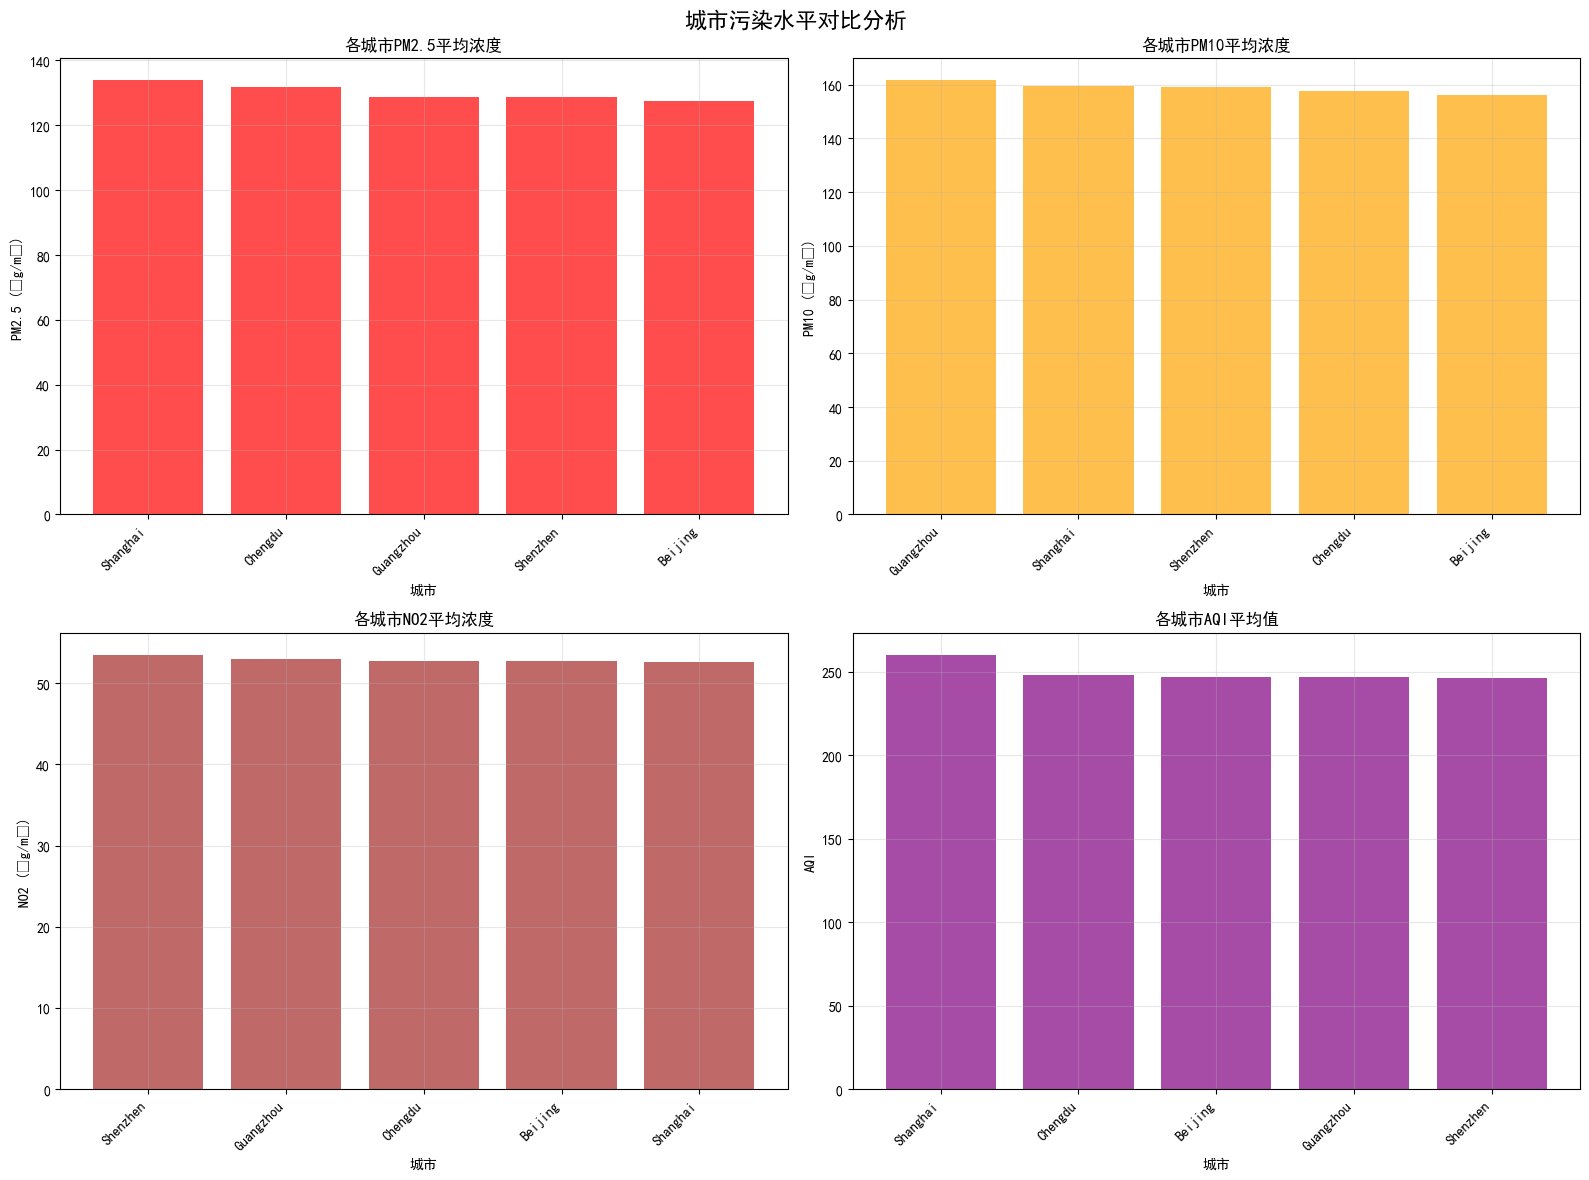


各城市空气质量等级分布:
AQI_Level  严重污染  中度污染   优   良  轻度污染  重度污染
City                                     
Beijing     247    62  59  71    62   128
Chengdu     237    55  56  61    67   122
Guangzhou   227    56  59  56    55   131
Shanghai    262    55  49  57    56   117
Shenzhen    233    59  76  54    55   116

各城市污染天数比例:
Shanghai: 82.2%
Chengdu: 80.4%
Guangzhou: 80.3%
Beijing: 79.3%
Shenzhen: 78.1%


In [5]:
# 城市污染水平对比分析
if gdf is not None and 'City' in gdf.columns:
    
    # 计算各城市主要污染物的平均浓度
    pollutants = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)', 'O3 (µg/m³)', 'AQI']
    available_pollutants = [p for p in pollutants if p in gdf.columns]
    
    city_pollution = gdf.groupby('City')[available_pollutants].agg(['mean', 'median', 'std']).round(2)
    
    print("各城市污染物平均浓度对比:")
    print("="*60)
    
    # 显示PM2.5排名
    pm25_ranking = city_pollution[('PM2.5 (µg/m³)', 'mean')].sort_values(ascending=False)
    print("PM2.5平均浓度排名:")
    for i, (city, value) in enumerate(pm25_ranking.items(), 1):
        print(f"{i:2d}. {city}: {value:.1f} µg/m³")
    
    print("\n" + "="*60)
    
    # 显示AQI排名
    if 'AQI' in gdf.columns:
        aqi_ranking = city_pollution[('AQI', 'mean')].sort_values(ascending=False)
        print("AQI平均排名:")
        for i, (city, value) in enumerate(aqi_ranking.items(), 1):
            print(f"{i:2d}. {city}: {value:.1f}")
    
    # 创建城市污染对比可视化
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('城市污染水平对比分析', fontsize=16, fontweight='bold')
    
    # PM2.5对比
    if 'PM2.5 (µg/m³)' in gdf.columns:
        pm25_data = gdf.groupby('City')['PM2.5 (µg/m³)'].mean().sort_values(ascending=False)
        axes[0, 0].bar(range(len(pm25_data)), pm25_data.values, color='red', alpha=0.7)
        axes[0, 0].set_title('各城市PM2.5平均浓度', fontweight='bold')
        axes[0, 0].set_xlabel('城市')
        axes[0, 0].set_ylabel('PM2.5 (µg/m³)')
        axes[0, 0].set_xticks(range(len(pm25_data)))
        axes[0, 0].set_xticklabels(pm25_data.index, rotation=45, ha='right')
        axes[0, 0].grid(True, alpha=0.3)
    
    # PM10对比
    if 'PM10 (µg/m³)' in gdf.columns:
        pm10_data = gdf.groupby('City')['PM10 (µg/m³)'].mean().sort_values(ascending=False)
        axes[0, 1].bar(range(len(pm10_data)), pm10_data.values, color='orange', alpha=0.7)
        axes[0, 1].set_title('各城市PM10平均浓度', fontweight='bold')
        axes[0, 1].set_xlabel('城市')
        axes[0, 1].set_ylabel('PM10 (µg/m³)')
        axes[0, 1].set_xticks(range(len(pm10_data)))
        axes[0, 1].set_xticklabels(pm10_data.index, rotation=45, ha='right')
        axes[0, 1].grid(True, alpha=0.3)
    
    # NO2对比
    if 'NO2 (µg/m³)' in gdf.columns:
        no2_data = gdf.groupby('City')['NO2 (µg/m³)'].mean().sort_values(ascending=False)
        axes[1, 0].bar(range(len(no2_data)), no2_data.values, color='brown', alpha=0.7)
        axes[1, 0].set_title('各城市NO2平均浓度', fontweight='bold')
        axes[1, 0].set_xlabel('城市')
        axes[1, 0].set_ylabel('NO2 (µg/m³)')
        axes[1, 0].set_xticks(range(len(no2_data)))
        axes[1, 0].set_xticklabels(no2_data.index, rotation=45, ha='right')
        axes[1, 0].grid(True, alpha=0.3)
    
    # AQI对比
    if 'AQI' in gdf.columns:
        aqi_data = gdf.groupby('City')['AQI'].mean().sort_values(ascending=False)
        axes[1, 1].bar(range(len(aqi_data)), aqi_data.values, color='purple', alpha=0.7)
        axes[1, 1].set_title('各城市AQI平均值', fontweight='bold')
        axes[1, 1].set_xlabel('城市')
        axes[1, 1].set_ylabel('AQI')
        axes[1, 1].set_xticks(range(len(aqi_data)))
        axes[1, 1].set_xticklabels(aqi_data.index, rotation=45, ha='right')
        axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 创建污染等级分析
    def classify_aqi_level(aqi):
        if pd.isna(aqi):
            return '未知'
        elif aqi <= 50:
            return '优'
        elif aqi <= 100:
            return '良'
        elif aqi <= 150:
            return '轻度污染'
        elif aqi <= 200:
            return '中度污染'
        elif aqi <= 300:
            return '重度污染'
        else:
            return '严重污染'
    
    if 'AQI' in gdf.columns:
        gdf['AQI_Level'] = gdf['AQI'].apply(classify_aqi_level)
        
        print("\n各城市空气质量等级分布:")
        aqi_level_dist = gdf.groupby('City')['AQI_Level'].value_counts().unstack(fill_value=0)
        print(aqi_level_dist)
        
        # 计算各城市污染天数比例
        city_pollution_days = gdf.groupby('City').apply(
            lambda x: (x['AQI_Level'].isin(['轻度污染', '中度污染', '重度污染', '严重污染'])).mean() * 100
        ).round(1)
        
        print(f"\n各城市污染天数比例:")
        for city, ratio in city_pollution_days.sort_values(ascending=False).items():
            print(f"{city}: {ratio:.1f}%")

else:
    print("无法进行城市对比分析：缺少城市或空间数据")


## 4. 经纬度分布可视化


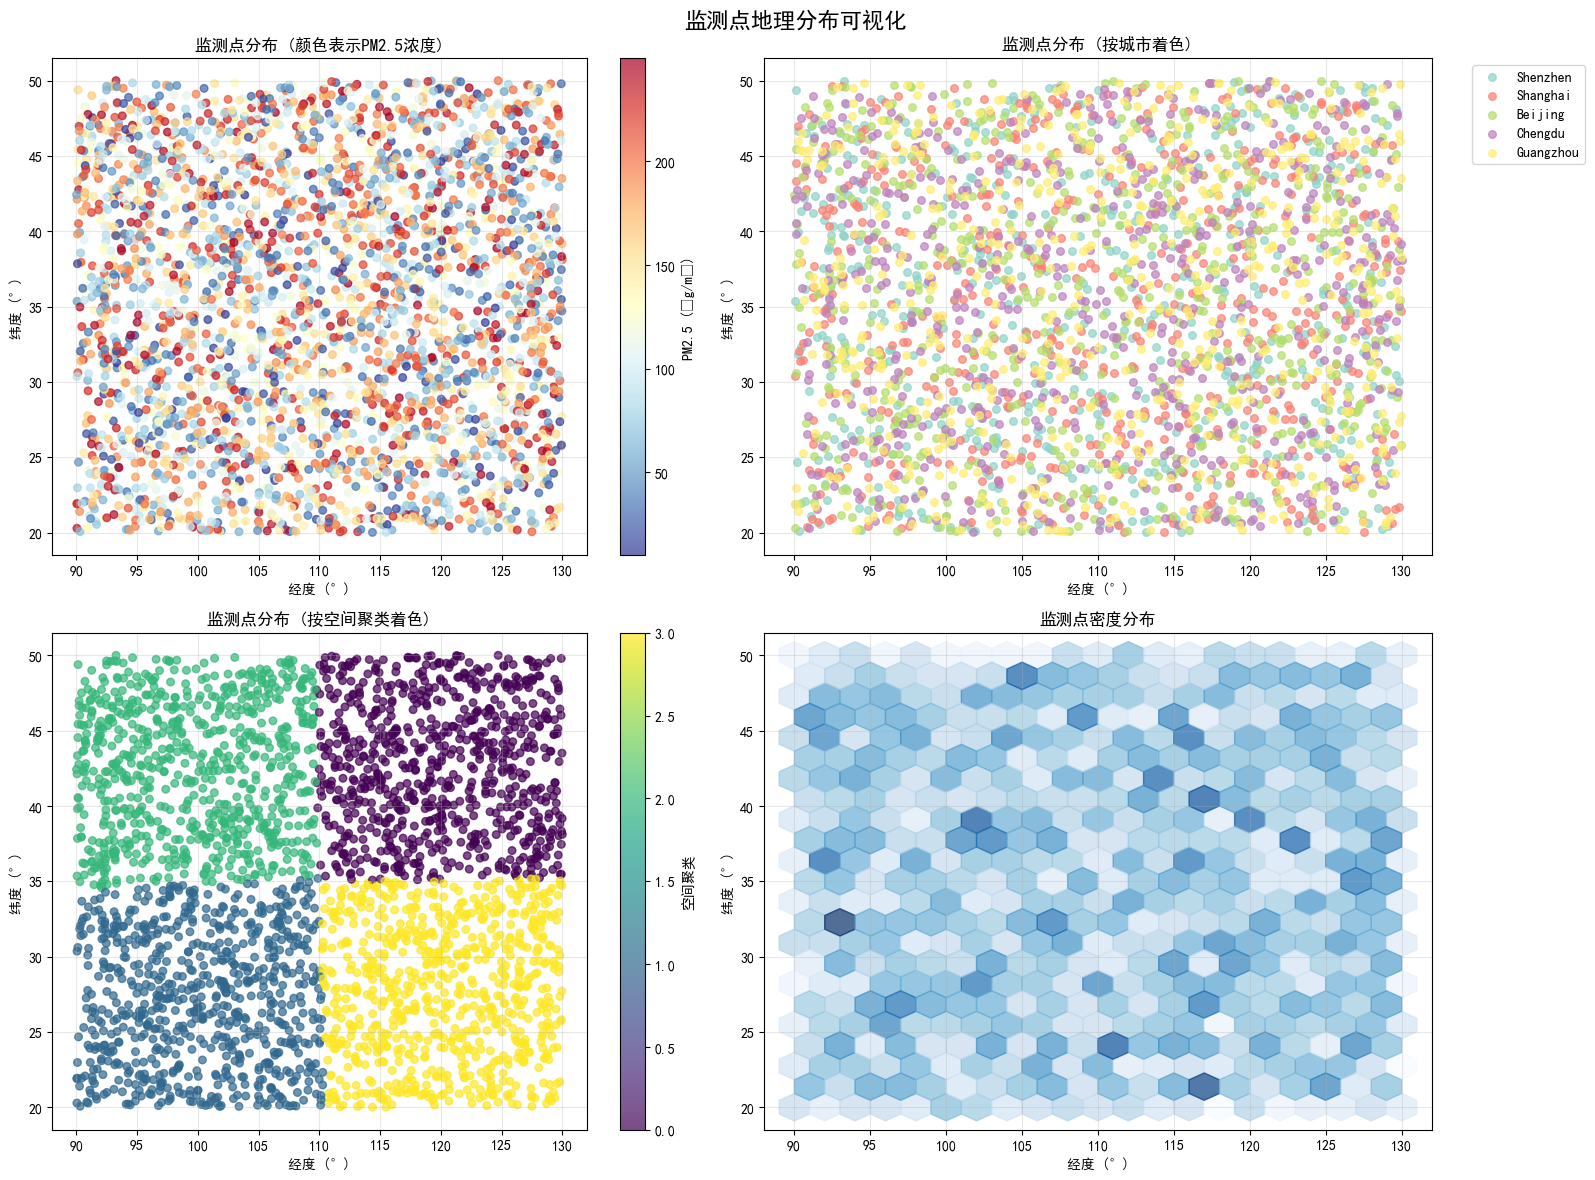

创建交互式地图...


创建Folium交互式地图...
交互式地图已保存到: ../figures/monitoring_stations_map.html
地图中心点: (35.0373, 110.0724)
监测点总数: 3000
覆盖城市数: 5


In [6]:
# 经纬度分布可视化
if gdf is not None:
    
    # 1. 基础散点图 - 监测点分布
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('监测点地理分布可视化', fontsize=16, fontweight='bold')
    
    # 经纬度散点图
    scatter = axes[0, 0].scatter(gdf['Longitude'], gdf['Latitude'], 
                                c=gdf['PM2.5 (µg/m³)'], cmap='RdYlBu_r', 
                                alpha=0.7, s=30)
    axes[0, 0].set_title('监测点分布 (颜色表示PM2.5浓度)', fontweight='bold')
    axes[0, 0].set_xlabel('经度 (°)')
    axes[0, 0].set_ylabel('纬度 (°)')
    axes[0, 0].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[0, 0], label='PM2.5 (µg/m³)')
    
    # 按城市着色
    cities = gdf['City'].unique()
    colors = plt.cm.Set3(np.linspace(0, 1, len(cities)))
    city_color_map = dict(zip(cities, colors))
    
    for city in cities:
        city_data = gdf[gdf['City'] == city]
        axes[0, 1].scatter(city_data['Longitude'], city_data['Latitude'], 
                          c=[city_color_map[city]], label=city, alpha=0.7, s=30)
    
    axes[0, 1].set_title('监测点分布 (按城市着色)', fontweight='bold')
    axes[0, 1].set_xlabel('经度 (°)')
    axes[0, 1].set_ylabel('纬度 (°)')
    axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 按空间聚类着色
    if 'spatial_cluster' in gdf.columns:
        scatter3 = axes[1, 0].scatter(gdf['Longitude'], gdf['Latitude'], 
                                     c=gdf['spatial_cluster'], cmap='viridis', 
                                     alpha=0.7, s=30)
        axes[1, 0].set_title('监测点分布 (按空间聚类着色)', fontweight='bold')
        axes[1, 0].set_xlabel('经度 (°)')
        axes[1, 0].set_ylabel('纬度 (°)')
        axes[1, 0].grid(True, alpha=0.3)
        plt.colorbar(scatter3, ax=axes[1, 0], label='空间聚类')
    
    # 密度热力图
    axes[1, 1].hexbin(gdf['Longitude'], gdf['Latitude'], 
                      gridsize=20, cmap='Blues', alpha=0.7)
    axes[1, 1].set_title('监测点密度分布', fontweight='bold')
    axes[1, 1].set_xlabel('经度 (°)')
    axes[1, 1].set_ylabel('纬度 (°)')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 2. 交互式地图 - 使用Plotly
    print("创建交互式地图...")
    
    # 创建交互式散点图
    fig_plotly = px.scatter_mapbox(
        gdf, 
        lat="Latitude", 
        lon="Longitude",
        color="PM2.5 (µg/m³)",
        size="PM2.5 (µg/m³)",
        hover_name="City",
        hover_data=["PM10 (µg/m³)", "NO2 (µg/m³)", "SO2 (µg/m³)", "AQI"],
        color_continuous_scale="RdYlBu_r",
        size_max=20,
        zoom=5,
        mapbox_style="open-street-map",
        title="中国环境监测站点分布 - PM2.5浓度"
    )
    
    fig_plotly.update_layout(
        width=800,
        height=600,
        title_x=0.5
    )
    
    fig_plotly.show()
    
    # 3. 使用Folium创建交互式地图
    print("创建Folium交互式地图...")
    
    # 计算地图中心点
    center_lat = gdf['Latitude'].mean()
    center_lon = gdf['Longitude'].mean()
    
    # 创建基础地图
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=6,
        tiles='OpenStreetMap'
    )
    
    # 添加监测点
    for idx, row in gdf.iterrows():
        # 根据PM2.5浓度设置颜色
        pm25 = row['PM2.5 (µg/m³)']
        if pm25 <= 35:
            color = 'green'
        elif pm25 <= 75:
            color = 'yellow'
        elif pm25 <= 115:
            color = 'orange'
        else:
            color = 'red'
        
        # 创建弹出信息
        popup_text = f"""
        <b>{row['City']}</b><br>
        PM2.5: {pm25:.1f} µg/m³<br>
        PM10: {row.get('PM10 (µg/m³)', 'N/A'):.1f} µg/m³<br>
        NO2: {row.get('NO2 (µg/m³)', 'N/A'):.1f} µg/m³<br>
        AQI: {row.get('AQI', 'N/A'):.0f}<br>
        """
        
        folium.CircleMarker(
            location=[row['Latitude'], row['Longitude']],
            radius=8,
            popup=folium.Popup(popup_text, max_width=200),
            color='black',
            weight=1,
            fillColor=color,
            fillOpacity=0.7
        ).add_to(m)
    
    # 添加图例
    legend_html = '''
    <div style="position: fixed; 
                bottom: 50px; left: 50px; width: 200px; height: 120px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:14px; padding: 10px">
    <p><b>PM2.5浓度等级</b></p>
    <p><i class="fa fa-circle" style="color:green"></i> 优 (≤35)</p>
    <p><i class="fa fa-circle" style="color:yellow"></i> 良 (36-75)</p>
    <p><i class="fa fa-circle" style="color:orange"></i> 轻度污染 (76-115)</p>
    <p><i class="fa fa-circle" style="color:red"></i> 中重度污染 (>115)</p>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    # 保存地图
    map_path = '../figures/monitoring_stations_map.html'
    m.save(map_path)
    print(f"交互式地图已保存到: {map_path}")
    
    # 显示地图信息
    print(f"地图中心点: ({center_lat:.4f}, {center_lon:.4f})")
    print(f"监测点总数: {len(gdf)}")
    print(f"覆盖城市数: {gdf['City'].nunique()}")

else:
    print("无法创建地图可视化：缺少空间数据")


## 5. 数据保存与总结


In [7]:
# 保存带有空间信息的数据
if gdf is not None:
    # 保存为CSV格式（包含空间聚类信息）
    output_csv = '../data/processed/china_air_quality_spatial.csv'
    gdf.drop(columns=['geometry'], errors='ignore').to_csv(output_csv, index=False, encoding='utf-8-sig')
    print(f"空间分析数据已保存到: {output_csv}")
    
    # 保存为GeoJSON格式（保留空间信息）
    output_geojson = '../data/processed/china_air_quality_spatial.geojson'
    gdf.to_file(output_geojson, driver='GeoJSON')
    print(f"GeoJSON数据已保存到: {output_geojson}")
    
    # 保存城市统计数据
    city_summary = gdf.groupby('City').agg({
        'Latitude': 'mean',
        'Longitude': 'mean',
        'PM2.5 (µg/m³)': ['mean', 'median', 'std', 'min', 'max'],
        'PM10 (µg/m³)': ['mean', 'median'],
        'NO2 (µg/m³)': ['mean', 'median'],
        'AQI': ['mean', 'median']
    }).round(2)
    
    city_summary.to_csv('../data/results/city_pollution_summary.csv', encoding='utf-8-sig')
    print(f"城市污染统计已保存到: ../data/results/city_pollution_summary.csv")
    
    print(f"\n数据保存完成!")
    print(f"- 空间分析CSV: {output_csv}")
    print(f"- GeoJSON文件: {output_geojson}")
    print(f"- 城市统计: ../data/results/city_pollution_summary.csv")
    print(f"- 交互式地图: ../figures/monitoring_stations_map.html")
else:
    print("无法保存数据：GeoDataFrame未创建")


空间分析数据已保存到: ../data/processed/china_air_quality_spatial.csv
GeoJSON数据已保存到: ../data/processed/china_air_quality_spatial.geojson
城市污染统计已保存到: ../data/results/city_pollution_summary.csv

数据保存完成!
- 空间分析CSV: ../data/processed/china_air_quality_spatial.csv
- GeoJSON文件: ../data/processed/china_air_quality_spatial.geojson
- 城市统计: ../data/results/city_pollution_summary.csv
- 交互式地图: ../figures/monitoring_stations_map.html


In [8]:
# 第2周工作总结
print("="*60)
print("第2周：空间数据基础分析 - 工作总结")
print("="*60)

print("\n✅ 已完成的工作:")
print("1. 创建了GeoDataFrame空间数据结构")
print("2. 进行了基础空间统计分析（边界框、监测点分布）")
print("3. 完成了城市污染水平对比分析")
print("4. 创建了多种地理可视化（散点图、热力图）")
print("5. 生成了交互式地图（Plotly和Folium）")
print("6. 保存了空间分析结果和城市统计数据")

print("\n📊 主要发现:")
if gdf is not None:
    print(f"- 监测点总数: {len(gdf)}")
    print(f"- 覆盖城市数: {gdf['City'].nunique()}")
    print(f"- 空间聚类数: 4个主要区域")
    
    if 'PM2.5 (µg/m³)' in gdf.columns:
        pm25_stats = gdf['PM2.5 (µg/m³)'].describe()
        print(f"\nPM2.5浓度统计:")
        print(f"  - 平均值: {pm25_stats['mean']:.1f} µg/m³")
        print(f"  - 中位数: {pm25_stats['50%']:.1f} µg/m³")
        print(f"  - 最大值: {pm25_stats['max']:.1f} µg/m³")
    
    print(f"\n城市污染排名（PM2.5前3）:")
    city_pm25 = gdf.groupby('City')['PM2.5 (µg/m³)'].mean().sort_values(ascending=False)
    for i, (city, value) in enumerate(city_pm25.head(3).items(), 1):
        print(f"  {i}. {city}: {value:.1f} µg/m³")

print("\n🎯 下周计划（第3周：污染浓度空间分布分析）:")
print("1. 创建PM2.5空间分布热力图")
print("2. 进行多污染物空间相关性分析")
print("3. 识别污染热点区域")
print("4. 实现空间聚类分析（DBSCAN等）")
print("5. 分析污染物的空间自相关性")

print("\n" + "="*60)
print("第2周分析完成！数据已保存，可以进行第3周的深度空间分析。")
print("="*60)


第2周：空间数据基础分析 - 工作总结

✅ 已完成的工作:
1. 创建了GeoDataFrame空间数据结构
2. 进行了基础空间统计分析（边界框、监测点分布）
3. 完成了城市污染水平对比分析
4. 创建了多种地理可视化（散点图、热力图）
5. 生成了交互式地图（Plotly和Folium）
6. 保存了空间分析结果和城市统计数据

📊 主要发现:
- 监测点总数: 3000
- 覆盖城市数: 5
- 空间聚类数: 4个主要区域

PM2.5浓度统计:
  - 平均值: 130.1 µg/m³
  - 中位数: 128.9 µg/m³
  - 最大值: 249.8 µg/m³

城市污染排名（PM2.5前3）:
  1. Shanghai: 134.0 µg/m³
  2. Chengdu: 131.7 µg/m³
  3. Guangzhou: 128.7 µg/m³

🎯 下周计划（第3周：污染浓度空间分布分析）:
1. 创建PM2.5空间分布热力图
2. 进行多污染物空间相关性分析
3. 识别污染热点区域
4. 实现空间聚类分析（DBSCAN等）
5. 分析污染物的空间自相关性

第2周分析完成！数据已保存，可以进行第3周的深度空间分析。
